<a href="https://colab.research.google.com/github/giyuubin/group-project/blob/main/code/4_2%EA%B7%B8%EB%A6%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 코랩 한글 폰트 설치 (한글 깨짐 방지용)
# ⚠️ 주의: 최초 1회 실행 후, 코랩 상단 메뉴에서 [런타임] -> [세션 다시 시작]을 누르고 아래 코드를 실행해야 한글이 적용됩니다.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (34.0 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and direct

/tmp/ipykernel_1719/1623568019.py:60: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.savefig('class_imbalance_donut.png', transparent=True, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1719/1623568019.py:60: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.savefig('class_imbalance_donut.png', transparent=True, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1719/1623568019.py:60: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.savefig('class_imbalance_donut.png', transparent=True, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1719/1623568019.py:60: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) DejaVu Sans.
  plt.savefig('class_imbalance_donut.png', transparent=True, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1719/1623568019.py:60: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig('class_im

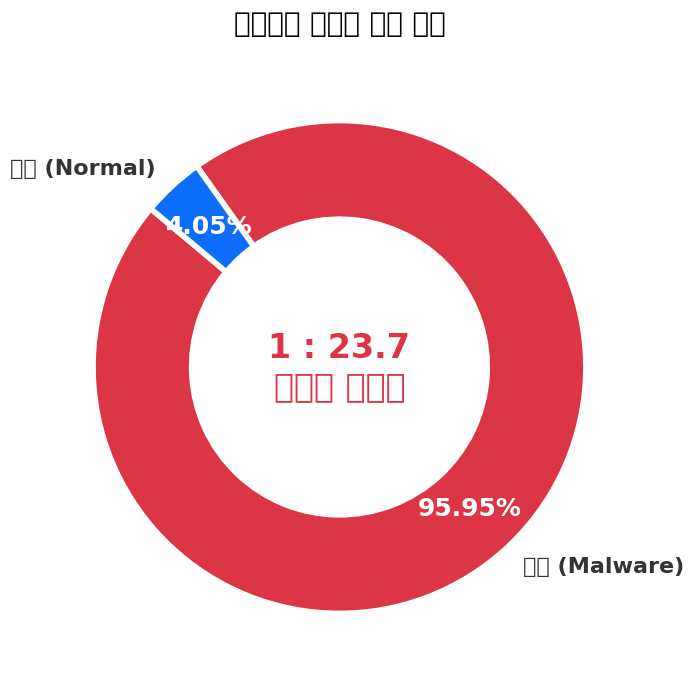

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 적용
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# ==========================================
# 2. 데이터 연동 (CSV 파일 읽기)
# ==========================================
# TODO: 실제 코랩에 업로드한 csv 파일의 경로와 이름으로 변경하세요.
# 예시: df = pd.read_csv('processed_data.csv')

# --- 테스트를 위해 임시로 선배님의 수치를 사용합니다 ---
# 만약 csv를 연동하셨다면 아래 두 줄을 지우고,
# counts = df['malware'].value_counts()
# sizes = [counts[1], counts[0]] # 1이 악성, 0이 정상
# 로 변경하시면 됩니다.
sizes = [45651, 1929]
# -----------------------------------------------------

labels = ['악성 (Malware)', '정상 (Normal)']

# 색상 설정 (PPT에 잘 어울리는 모던한 톤)
# 악성은 경고 느낌의 붉은색, 정상은 신뢰를 주는 푸른색
colors = ['#dc3545', '#0d6efd']

# ==========================================
# 3. 도넛 차트 그리기
# ==========================================
fig, ax = plt.subplots(figsize=(8, 8))

# wedgeprops={'width': 0.4} 속성이 원을 '도넛 모양'으로 만들어줍니다.
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%', # 소수점 2자리까지 퍼센트 표시 (95.95%)
    startangle=140,    # 차트 시작 각도 (시각적 안정감을 위해 틀어줌)
    pctdistance=0.78,  # 퍼센트 텍스트 위치 (도넛 내부 중앙)
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 4}, # 테두리를 굵은 흰색으로 줘서 깔끔하게 분리
    textprops={'fontsize': 16, 'fontweight': 'bold', 'color': '#333333'} # 바깥 라벨 폰트
)

# 도넛 내부의 퍼센트(95.95%) 글씨만 흰색으로 변경하여 가독성 극대화
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(18)

# 도넛 텅 빈 중앙에 핵심 메시지(1:23.7) 텍스트 삽입
plt.text(0, 0, '1 : 23.7\n극단적 불균형', ha='center', va='center', fontsize=24, fontweight='bold', color='#dc3545')

# 차트 제목
plt.title('데이터셋 클래스 분포 현황', fontsize=20, fontweight='bold', pad=20)

# ==========================================
# 4. 고해상도 이미지로 저장 (PPT용)
# ==========================================
# 투명 배경(transparent=True)으로 저장해야 PPT 슬라이드 배경색과 자연스럽게 섞입니다.
plt.savefig('class_imbalance_donut.png', transparent=True, dpi=300, bbox_inches='tight')

# 화면에 출력
plt.show()